In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../../../archive/Hotel_Reviews_NLP.csv')

In [3]:
df.head()

,Hotel_Name,Hotel_Address,Total_Number_of_Reviews,Average_Score,Reviewer_Score,Negative_Sentiment,Positive_Sentiment,Reviewer_Nationality,Leisure_trip,Couple,Solo_traveler,Business_trip,Group,Family_with_young_children,Family_with_older_children,With_a_pet,Negative_Review,Positive_Review
0,South Place Hotel,"London, United Kingdom",326,9.3,2.5,-0.9849,-0.9820,Brazil,0,1,0,0,0,0,0,0,No windows claustrophobic place even superior ...,Bathroom Shower We going stay twice hotel 2 ni...
1,Park Plaza County Hall London,"London, United Kingdom",2223,8.4,3.8,-0.9780,-0.9780,Saudi Arabia,1,0,0,0,0,1,0,0,I completely disappointed mad since reception ...,I completely disappointed mad since reception ...
2,Britannia International Hotel Canary Wharf,"London, United Kingdom",4789,6.8,3.3,-0.4767,-0.9751,Australia,1,1,0,0,0,0,0,0,everything terrible,get everything extra internet parking breakfas...
3,Caesar Hotel,"London, United Kingdom",317,8.3,3.3,0.1082,-0.9721,United States Minor Outlying Islands,1,0,0,0,1,0,0,0,Everything I worst experience ever best friend...,I didnt like anythig Room small Asked upgrade ...
4,Hotel Da Vinci,"Milan, Italy",1877,7.8,2.5,0.0000,-0.9703,United Kingdom,1,0,0,0,0,1,0,0,No Negative,Very rude manager abusive staff reception Dirt...


In [6]:
df['Reviewer_Nationality'] = df['Reviewer_Nationality'].str.strip()
df = df.dropna()

<Axes: >

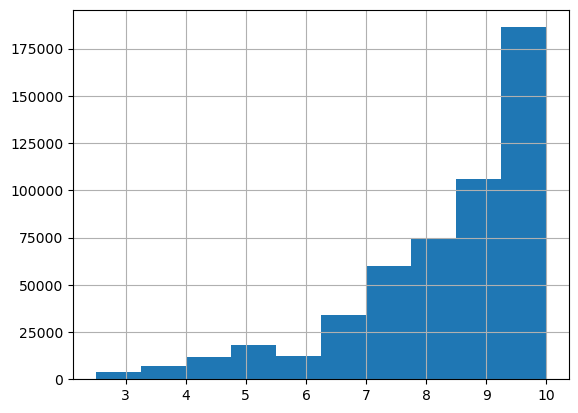

In [7]:
df['Reviewer_Score'].hist()

In [14]:
countries = df.groupby('Reviewer_Nationality').size().sort_values(ascending=False)

<Axes: xlabel='Reviewer_Nationality'>

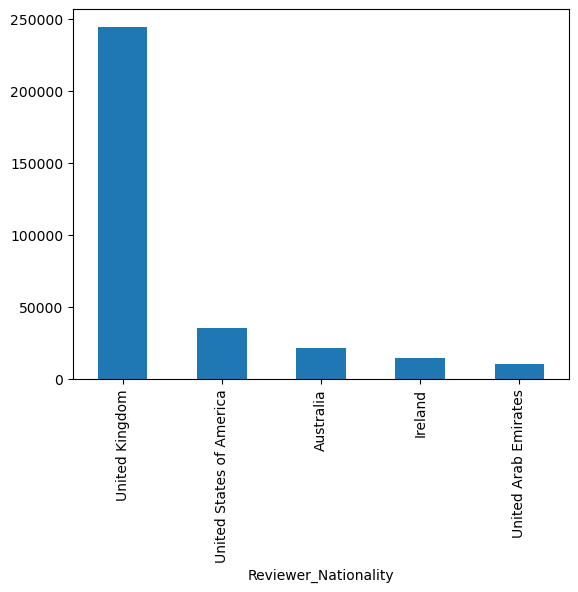

In [15]:
countries.head(5).plot(kind='bar')

In [36]:
top5countries = df[(df['Reviewer_Nationality']==countries.index[0]) | (df['Reviewer_Nationality']==countries.index[1]) | (df['Reviewer_Nationality']==countries.index[2]) |
                    (df['Reviewer_Nationality']==countries.index[3]) | (df['Reviewer_Nationality']==countries.index[4]) ]

<Axes: xlabel='Reviewer_Score'>

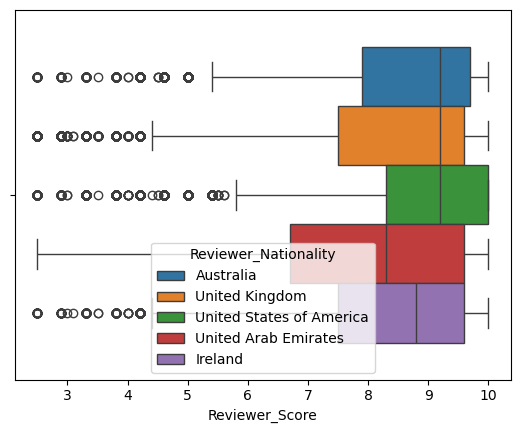

In [39]:
sns.boxplot(x = 'Reviewer_Score', data=top5countries, hue='Reviewer_Nationality', legend='brief')

<Axes: xlabel='Total_Number_of_Reviews'>

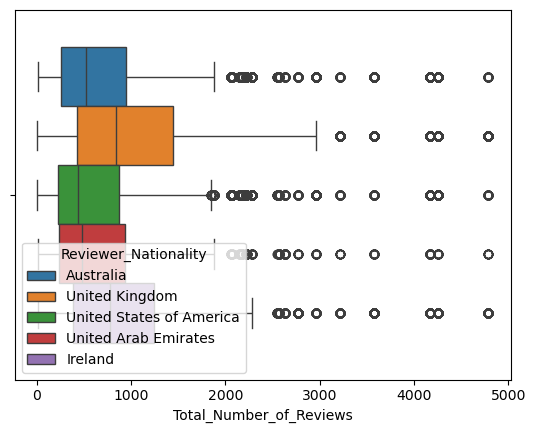

In [40]:
sns.boxplot(x = 'Total_Number_of_Reviews', data=top5countries, hue='Reviewer_Nationality', legend='brief')

<Axes: ylabel='Frequency'>

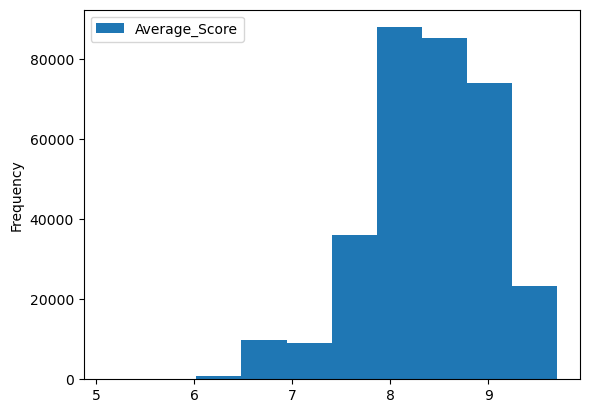

In [ ]:
top5countries.plot.hist(x='Total_Number_of_Reviews', y='Average_Score')

<Axes: xlabel='Total_Number_of_Reviews', ylabel='Average_Score'>

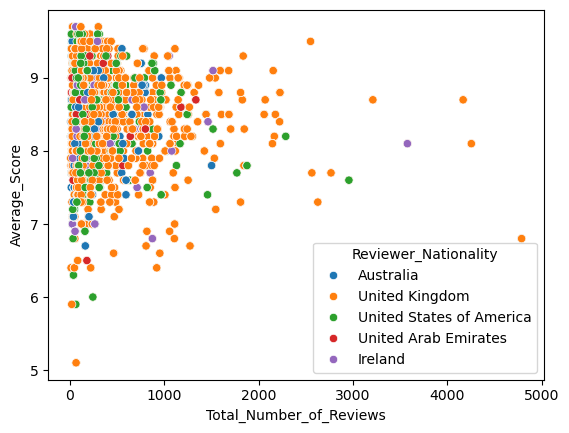

In [47]:
sns.scatterplot(top5countries,x='Total_Number_of_Reviews',y='Average_Score',hue='Reviewer_Nationality')

In [48]:
hotel_df = df.groupby('Hotel_Name').agg({
    'Reviewer_Score': ['mean', 'count'],
    'Positive_Sentiment': 'mean',
    'Negative_Sentiment': 'mean'
})

In [49]:
hotel_df.columns = ['Avg_Score', 'Review_Count', 'Pos_Sent', 'Neg_Sent']
hotel_df = hotel_df.reset_index()

In [50]:
C = hotel_df['Avg_Score'].mean()
m = hotel_df['Review_Count'].quantile(0.75)

hotel_df['Weighted_Score'] = (
    (hotel_df['Review_Count'] / (hotel_df['Review_Count'] + m)) * hotel_df['Avg_Score'] +
    (m / (hotel_df['Review_Count'] + m)) * C
)

In [51]:
top_hotels = hotel_df.sort_values('Weighted_Score', ascending=False)

In [53]:
top_hotels.head(5)

,Hotel_Name,Avg_Score,Review_Count,Pos_Sent,Neg_Sent,Weighted_Score
836,Intercontinental London The O2,9.451513,2545,0.646447,0.031214,9.310778
1247,Shangri La Hotel at The Shard London,9.366787,1108,0.573258,0.030611,9.117398
633,Hotel Esther a,9.265191,1830,0.706075,0.046066,9.114797
585,Hotel Berna,9.332208,1037,0.708551,0.037622,9.080716
42,Amba Hotel Charing Cross,9.395519,781,0.703419,0.046921,9.068313


In [54]:
def recommend(min_reviews=50):
    return hotel_df[hotel_df['Review_Count'] > min_reviews] \
        .sort_values('Weighted_Score', ascending=False) \
        .head(10)

In [55]:
df['High_Score'] = (df['Reviewer_Score'] >= 8).astype(int)

In [57]:
from sklearn.model_selection import train_test_split, cross_val_score

X = df[['Positive_Sentiment', 'Negative_Sentiment']]
y = df['High_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [60]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report, precision_recall_curve
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (train): %0.1f%% " % (accuracy * 100))
print(classification_report(y_test,y_pred))

Accuracy (train): 69.3% 
              precision    recall  f1-score   support

           0       0.59      0.40      0.48     53883
           1       0.72      0.85      0.78    100088

    accuracy                           0.69    153971
   macro avg       0.66      0.62      0.63    153971
weighted avg       0.68      0.69      0.68    153971

